In [76]:
## install finrl library if not installed

import pkg_resources
import pip
installedPackages = {pkg.key for pkg in pkg_resources.working_set} # list of installed packages

required = {'pandas','numpy', 'matplotlib','tensorflow','scikit-learn','PyPortfolioOpt','empyrical','keras-tuner','shap'

            }
missing = required - installedPackages
if missing:

    !pip install pandas
    !pip install numpy
    !pip install matplotlib
    !pip install tensorflow
    !pip install scikit-learn
    !pip install PyPortfolioOpt
    !pip install empyrical
    !pip install -q -U keras-tuner
    !pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 5.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("drive/My Drive/Asset_Allocation")

Mounted at /content/drive


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from pandas_datareader import data as pdr

%matplotlib inline

from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import objective_functions
from pypfopt import risk_models
from pypfopt import expected_returns
from empyrical import sharpe_ratio, annual_return
import warnings
warnings.filterwarnings('ignore')

In [4]:
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

In [9]:
def capital(weights,test_df_pivot,unique_trade_date,portfolio):
  for t,t_1 in zip(unique_trade_date[:-1],unique_trade_date[1::]):
    weight = weights.loc[t]
    #current capital
    cap = portfolio.loc[t,'account_value']
    #current cash invested for each stock
    current_cash = [element * cap for element in list(weight.values)]
    # current held shares
    current_shares = list(np.array(current_cash)
                                      / np.array(test_df_pivot.loc[t]))
    # next time period price
    next_price = np.array(test_df_pivot.loc[t_1])
    ##next_price * current share to calculate next total account value

    portfolio.loc[t_1, 'account_value'] = np.dot(current_shares, next_price)

  return portfolio

def max_sharpe_weights(df_ret,df_cov,unique_trade_date):
  weights = pd.DataFrame()
  for t,t_1 in zip(unique_trade_date[:-1],unique_trade_date[1::]):

    mu = df_ret[df_ret.Date == str(t)].iloc[::,1::]*12
    sigma = df_cov[df_cov.Date == str(t)].iloc[::,1::].set_index('Ticker')*12


    try:
      ef = EfficientFrontier(mu.iloc[0],sigma)
      ef.add_objective(objective_functions.L2_reg, gamma=0.1)
      raw_weights = ef.max_sharpe( )
    except:
      print('min_volatility')
      ef = EfficientFrontier(mu.iloc[0],sigma)
      raw_weights = ef.min_volatility()
    cleaned_weights = ef.clean_weights()
    max_sharpe_portfolio = pd.DataFrame(cleaned_weights, index=[0])
    max_sharpe_portfolio['Date'] = t
    weights = pd.concat([weights,max_sharpe_portfolio])

  return weights

In [37]:
train_df = pd.read_pickle('datasets/train_data_m1_month.pkl')
test_df = pd.read_pickle('datasets/test_data_m1_month.pkl')

In [38]:
test_df.Date.min(),test_df.Date.max(),train_df.Date.min(),train_df.Date.max()

(Timestamp('2022-01-01 00:00:00'),
 Timestamp('2024-11-01 00:00:00'),
 Timestamp('2010-01-01 00:00:00'),
 Timestamp('2021-12-01 00:00:00'))

In [39]:
test_df.head()

,Date,Ticker,close,high,low,open,volume,monthly_return,target,monthly_return_6_sma,...,wt2,supertrend_ub,supertrend_lb,vwma_3,gdp,unemployment rate,consumer price index,federal funds rate,interest rate,federal debt
148,2022-01-01,AAPL,171.963135,179.991627,152.206755,174.963982,2108446000,-0.015712,-0.055270,0.032750,...,70.117991,211.120358,123.331121,165.629770,25215.491000,4.000000,282.390000,0.080000,0.070000,30400960.0
149,2022-02-01,AAPL,162.458786,173.802958,149.550243,171.205507,1627516300,-0.055270,0.058821,0.016717,...,70.682591,210.250214,123.331121,167.102232,25412.257667,3.900000,284.514667,0.163333,0.156667,30456834.0
150,2022-03-01,AAPL,172.014725,176.940408,147.869029,162.252016,2180800100,0.058821,-0.097131,0.037627,...,70.482980,210.250214,123.331121,165.469911,25609.024333,3.800000,286.639333,0.246667,0.243333,30512708.0
151,2022-04-01,AAPL,155.306808,175.837071,153.070559,171.443354,1687795600,-0.097131,-0.055883,0.011663,...,68.725265,210.250214,123.331121,163.230305,25805.791000,3.700000,288.764000,0.330000,0.330000,30568582.0
152,2022-05-01,AAPL,146.627747,164.005558,130.638982,154.380783,2401040300,-0.055883,-0.080080,-0.014896,...,64.698106,203.264588,123.331121,157.385092,25961.197667,3.633333,290.835000,0.780000,0.746667,30688692.0


In [40]:
train_df.isna().sum().sum(),test_df.isna().sum().sum()

(0, 0)

## Monthly Target Weight Calculation with Efficent Frontier

In [41]:
test_df_pivot = test_df.pivot(index='Date', columns='Ticker', values='close')
data = pd.concat([train_df,test_df])
data_pivot = data.pivot(index='Date', columns='Ticker', values='close')
data_returns = data_pivot.pct_change() # get the assets monthly returns
#Get Next Month Return as Target
data_return_target = data.pivot(index='Date', columns='Ticker', values='target')
df_ret = (data_return_target*12).reset_index()
df_cov = (data_returns.rolling(12,min_periods=1).cov()*12).reset_index()
df_ret.head()

Ticker,Date,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
0,2010-01-01,0.784758,-0.383722,-0.670760,0.221904,0.506931,1.194309,0.830840,0.993325,0.029949,...,0.208665,0.724699,0.631580,0.425869,0.005679,0.454702,0.312731,0.475433,-0.029313,0.143740
1,2010-02-01,1.781637,0.684681,1.760472,0.964649,1.889619,1.219984,1.147903,0.838470,0.706350,...,0.316830,1.047347,0.888890,-0.001895,0.886481,0.308044,-0.421739,0.828355,0.866918,0.339562
2,2010-03-01,1.332259,-0.507351,0.117552,1.471939,-0.029749,1.000476,1.797180,0.414909,0.887779,...,0.512118,0.443134,-1.165518,-0.210531,1.842200,-0.642415,-0.866853,-0.105456,-0.820119,-0.357772
3,2010-04-01,-0.193497,-1.157913,-1.018819,-1.626199,-1.366835,-1.225027,0.130374,-1.679917,-1.115428,...,-1.862474,-0.558033,-1.963081,-0.115798,-0.221342,-0.300354,-0.480346,-2.363300,-0.396352,-0.689032
4,2010-05-01,-0.249919,0.190036,-1.549498,-0.051159,-0.199283,-0.136267,-0.098463,-0.958543,-0.873376,...,-1.249384,-0.800771,-2.675797,-0.218032,-1.114890,-0.053366,-0.276574,-0.265756,0.218026,-0.524707


In [42]:
unique_trade_date = data[data.Date>='2011-03-01'].Date.unique()
method2_weights  =  max_sharpe_weights(df_ret,df_cov,unique_trade_date)
method2_weights.Date = pd.to_datetime(method2_weights.Date)
method2_weights.head()

min_volatility


,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT,Date
0,0.00000,0.00000,0.0,0.02646,0.0,0.0,0.15062,0.0,0.0,0.0,...,0.00000,0.00441,0.19462,0.00000,0.02052,0.14884,0.00000,0.00000,0.0000,2011-03-01
0,0.00000,0.20916,0.0,0.00000,0.0,0.0,0.32024,0.0,0.0,0.0,...,0.00000,0.00000,0.25828,0.21233,0.00000,0.00000,0.00000,0.00000,0.0000,2011-04-01
0,0.00000,0.00000,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.04867,0.00000,0.00000,0.00000,0.00000,0.33623,0.01008,0.00000,0.0000,2011-05-01
0,0.60392,0.00000,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,2011-06-01
0,0.00000,0.00000,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.00000,0.02810,0.15957,0.00000,0.00000,0.00000,0.03044,0.12259,0.0021,2011-07-01


In [44]:
method2_weights.Date.nunique()

164

In [56]:
#method2_capital
unique_test_trade_date = test_df.Date.unique()
portfolio = pd.DataFrame(index = unique_test_trade_date[:-1], columns = ['account_value'])
initial_capital = 1000000
portfolio.loc[unique_test_trade_date[0],'account_value'] = initial_capital
method2_capital =  capital(method2_weights.set_index('Date'), test_df_pivot,unique_trade_date=unique_test_trade_date,portfolio=portfolio)

Sharpe Ratio: 5.713302954354978
Annual Return: 2.132331653961134


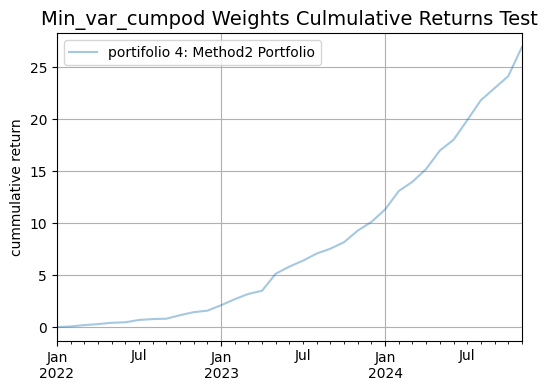

In [57]:
# Plotting the cummulative return
#method2
method2_returns = method2_capital.account_value.pct_change()
method2_cumpod =(method2_capital.account_value.pct_change().fillna(0)+1).cumprod()-1
method2_cumpod.name = "portifolio 4: Method2 Portfolio"

fig, ax = plt.subplots(figsize=(6,4))
method2_cumpod.plot(ax=ax, alpha=0.4);

plt.legend(loc="best");
plt.grid(True)
ax.set_ylabel("cummulative return");
ax.set_title('Min_var_cumpod Weights Culmulative Returns Test', fontsize=14)

print('Sharpe Ratio:', sharpe_ratio(method2_returns.values, period='monthly'))
print('Annual Return:', annual_return(method2_returns.values, period='monthly'))

In [58]:
def round_2_sum_1(df):
  df_rounded = df.round(2)
  diff = 1 - df_rounded.sum(1)
  max_col = df.idxmax(axis=1)
  for i in range(0,len(df_rounded)):
    df_rounded.loc[i,max_col.loc[i]] += diff.loc[i]
  return df_rounded

In [59]:
method2_weights.reset_index(drop=True, inplace=True)
method2_weights.iloc[::,:30] = round_2_sum_1(method2_weights.iloc[::,:30])
method2_weights

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT,Date
0,0.0,0.00,0.00,0.03,0.0,0.0,0.15,0.00,0.00,0.0,...,0.00,0.00,0.19,0.00,0.02,0.15,0.00,0.00,0.00,2011-03-01
1,0.0,0.21,0.00,0.00,0.0,0.0,0.32,0.00,0.00,0.0,...,0.00,0.00,0.26,0.21,0.00,0.00,0.00,0.00,0.00,2011-04-01
2,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.0,...,0.05,0.00,0.00,0.00,0.00,0.34,0.01,0.00,0.00,2011-05-01
3,0.6,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2011-06-01
4,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.0,...,0.00,0.03,0.16,0.00,0.00,0.00,0.03,0.12,0.00,2011-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,0.0,0.00,0.00,0.14,0.0,0.0,0.00,0.19,0.05,0.0,...,0.00,0.00,0.00,0.00,0.02,0.41,0.00,0.00,0.07,2024-06-01
160,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.10,0.00,0.0,...,0.06,0.00,0.14,0.00,0.00,0.06,0.00,0.00,0.35,2024-07-01
161,0.0,0.00,0.10,0.00,0.0,0.0,0.00,0.17,0.20,0.0,...,0.12,0.00,0.00,0.00,0.00,0.01,0.00,0.11,0.13,2024-08-01
162,0.0,0.00,0.00,0.00,0.0,0.0,0.02,0.33,0.00,0.0,...,0.00,0.07,0.00,0.00,0.00,0.00,0.48,0.00,0.00,2024-09-01


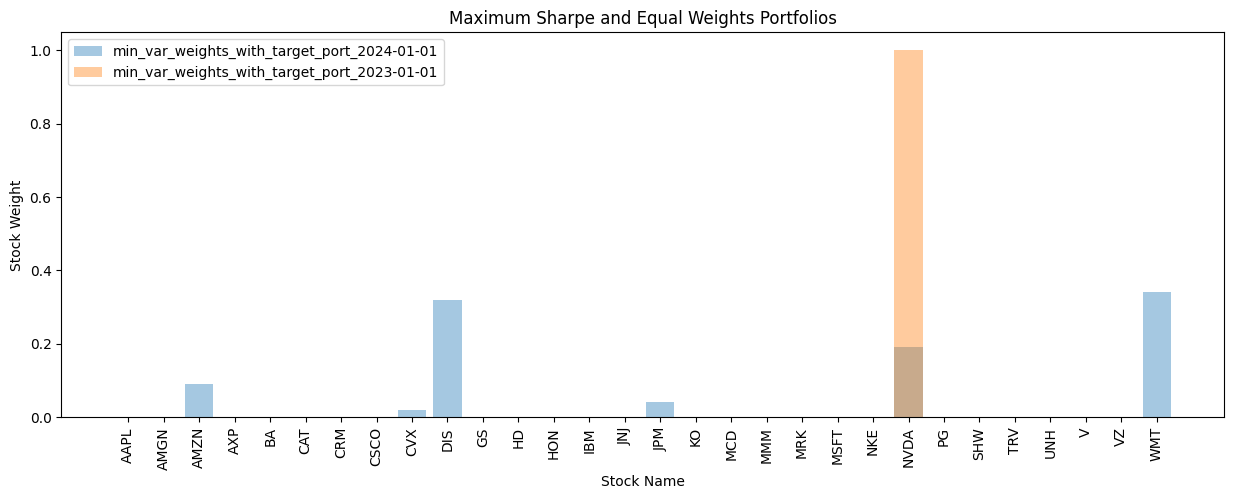

In [60]:
date1 = '2024-01-01'
date2 = '2023-01-01'
tickers = data_pivot.columns.tolist()
plt.subplots(figsize=(15,5))
plt.title('Maximum Sharpe and Equal Weights Portfolios')
plt.bar(tickers, method2_weights[method2_weights.Date == date1][tickers].values[0], alpha=0.4, label='min_var_weights_with_target_port_'+date1)
plt.bar(tickers, method2_weights[method2_weights.Date == date2][tickers].values[0], alpha=0.4, label='min_var_weights_with_target_port_'+date2)
plt.xlabel('Stock Name')
plt.ylabel('Stock Weight')
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [ ]:
#min_var_weights_with_target.iloc[::,:29].sum(axis=1)

In [61]:
method2_weights.to_pickle('datasets/M2_min_var_weights_with_target.pkl')

## Prepare the Data


In [62]:
method2_weights = pd.read_pickle('datasets/M2_min_var_weights_with_target.pkl')
train_df = pd.read_pickle('datasets/train_data_m1_month.pkl')
test_df = pd.read_pickle('datasets/test_data_m1_month.pkl')

In [63]:
method2_weights.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT,Date
0,0.0,0.00,0.0,0.03,0.0,0.0,0.15,0.0,0.0,0.0,...,0.00,0.00,0.19,0.00,0.02,0.15,0.00,0.00,0.0,2011-03-01
1,0.0,0.21,0.0,0.00,0.0,0.0,0.32,0.0,0.0,0.0,...,0.00,0.00,0.26,0.21,0.00,0.00,0.00,0.00,0.0,2011-04-01
2,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,...,0.05,0.00,0.00,0.00,0.00,0.34,0.01,0.00,0.0,2011-05-01
3,0.6,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,2011-06-01
4,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,...,0.00,0.03,0.16,0.00,0.00,0.00,0.03,0.12,0.0,2011-07-01


In [64]:
method2_weights.Date.max(), method2_weights.Date.min(), method2_weights.Date.nunique()

(Timestamp('2024-10-01 00:00:00'), Timestamp('2011-03-01 00:00:00'), 164)

In [93]:
method2_weights.Date = pd.to_datetime(method2_weights.Date)
unique_trade_date = method2_weights.Date.unique()
unique_test_trade_date = test_df[test_df.Date.isin(unique_trade_date)].Date.unique()
#Without target
train_df.sort_values(by=['Date','Ticker'],inplace=True)
test_df.sort_values(by=['Date','Ticker'],inplace=True)

data = pd.concat([train_df.drop(columns = ['target']),test_df.drop(columns = ['target'])])
data = data[data.Date.isin(unique_trade_date)]
data.reset_index(drop=True, inplace=True)
data.head()

,Date,Ticker,close,high,low,open,volume,monthly_return,monthly_return_6_sma,monthly_return_3_sma,...,wt2,supertrend_ub,supertrend_lb,vwma_3,gdp,unemployment rate,consumer price index,federal funds rate,interest rate,federal debt
0,2011-03-01,AAPL,10.499453,10.895920,9.829133,10.709134,11306458800,-0.013307,0.035128,0.026529,...,94.581175,13.208721,7.774601,10.383742,15488.842,9.1,223.124333,0.123333,0.116667,1.431876e+07
1,2011-03-01,AMGN,37.588436,38.467492,36.104589,36.688281,144456600,0.041302,-0.003750,-0.007834,...,-23.501073,47.948757,31.955444,37.890338,15488.842,9.1,223.124333,0.123333,0.116667,1.431876e+07
2,2011-03-01,AMZN,9.006500,9.078500,8.029500,8.676500,2379582000,0.039471,0.023871,0.001144,...,66.118775,11.762666,5.815814,8.796465,15488.842,9.1,223.124333,0.123333,0.116667,1.431876e+07
3,2011-03-01,AXP,37.069862,37.963804,34.601270,35.839668,161901000,0.037411,0.013919,0.018880,...,63.730218,38.744065,24.064024,36.429428,15488.842,9.1,223.124333,0.123333,0.116667,1.431876e+07
4,2011-03-01,BA,59.391903,59.825714,54.097802,57.785197,119791900,0.032628,0.021272,0.044569,...,57.290564,71.230850,39.594734,56.834968,15488.842,9.1,223.124333,0.123333,0.116667,1.431876e+07


In [82]:
data.Date.nunique(),method2_weights.Date.nunique()

(164, 164)

In [83]:
data.Date.max(),method2_weights.Date.max(),unique_test_trade_date.max()

(Timestamp('2024-10-01 00:00:00'),
 Timestamp('2024-10-01 00:00:00'),
 Timestamp('2024-10-01 00:00:00'))

In [90]:
def convert_to_array(df):
  # Melt the DataFrame to long format
  df_melted = df.melt(id_vars=['Date', 'Ticker'], var_name='Attribute', value_name='Value')

  # Pivot the DataFrame to get the desired format
  df_pivot = df_melted.pivot_table(index='Date', columns=['Ticker', 'Attribute'], values='Value')

  # Convert the pivot table to a 3D NumPy array
  data_array = df_pivot.to_numpy().reshape((df_pivot.shape[0], len(df['Ticker'].unique()), -1))
  return data_array

## Neural Network Model Weight Prediction

In [85]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from dateutil.relativedelta import relativedelta
import tensorflow as tf
import keras
from keras import layers
import random
from dateutil.relativedelta import relativedelta
import keras_tuner as kt

import shap
# Set seeds for reproducibility
#tf.random.set_seed(42)
#np.random.seed(42)
#random.seed(42)
#tf.config.experimental.enable_op_determinism()
#random_tensor = tf.random.stateless_uniform(shape=[2, 3], seed=[42, 42])

In [86]:
data

,Date,Ticker,close,high,low,open,volume,monthly_return,target,monthly_return_6_sma,...,wt2,supertrend_ub,supertrend_lb,vwma_3,gdp,unemployment rate,consumer price index,federal funds rate,interest rate,federal debt
0,2011-03-01,AAPL,10.499453,10.895920,9.829133,10.709134,11306458800,-0.013307,0.004648,0.035128,...,94.581175,13.208721,7.774601,10.383742,15488.842,9.1,223.124333,0.123333,0.116667,1.431876e+07
1,2011-03-01,AMGN,37.588436,38.467492,36.104589,36.688281,144456600,0.041302,0.063611,-0.003750,...,-23.501073,47.948757,31.955444,37.890338,15488.842,9.1,223.124333,0.123333,0.116667,1.431876e+07
2,2011-03-01,AMZN,9.006500,9.078500,8.029500,8.676500,2379582000,0.039471,0.087048,0.023871,...,66.118775,11.762666,5.815814,8.796465,15488.842,9.1,223.124333,0.123333,0.116667,1.431876e+07
3,2011-03-01,AXP,37.069862,37.963804,34.601270,35.839668,161901000,0.037411,0.085841,0.013919,...,63.730218,38.744065,24.064024,36.429428,15488.842,9.1,223.124333,0.123333,0.116667,1.431876e+07
4,2011-03-01,BA,59.391903,59.825714,54.097802,57.785197,119791900,0.032628,0.079129,0.021272,...,57.290564,71.230850,39.594734,56.834968,15488.842,9.1,223.124333,0.123333,0.116667,1.431876e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,2024-10-01,TRV,244.914932,268.436480,223.683786,232.516826,26677800,0.055082,0.081727,0.027404,...,58.111585,252.387885,189.546818,232.960565,29374.914,4.2,313.534000,5.330000,5.330000,3.546467e+07
4916,2024-10-01,UNH,562.343140,606.304531,540.925288,582.764813,74141000,-0.031091,0.080957,0.028710,...,40.571821,587.057922,440.370316,575.481171,29374.914,4.2,313.534000,5.330000,5.330000,3.546467e+07
4917,2024-10-01,V,289.299988,295.777663,272.721491,276.444424,128709800,0.054192,0.087045,0.013828,...,54.432952,319.418322,224.374066,276.352149,29374.914,4.2,313.534000,5.330000,5.330000,3.546467e+07
4918,2024-10-01,VZ,40.760166,43.807743,39.425035,43.498148,381990100,-0.061902,0.068886,0.017437,...,19.603427,52.054010,31.401296,41.288809,29374.914,4.2,313.534000,5.330000,5.330000,3.546467e+07


In [117]:
validation_size = 12*4 # Months
training_size = 7 # Years
tickers = method2_weights.iloc[::,:30].columns.tolist()
test_y_true = method2_weights[method2_weights.Date.isin(unique_test_trade_date)].copy()
all_features = test_df.drop(columns = ['Date','target','Ticker']).columns.tolist()

def neural_model_builder(hp):
  hp_l2 =  hp.Choice('l2', values=[0.05, 0.1])
  hp_l1 =  hp.Choice('l1', values=[0.01, 0.05])
  hp_lr = hp.Choice('learning_rate', values=[1e-3])
  model = keras.Sequential([
      layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(30, 95)),
      layers.MaxPooling1D(pool_size=2),
      layers.Flatten(),
      layers.Dense(64, activation='relu'),
      layers.BatchNormalization(),
      layers.Dense(32, activation='relu'),
     layers.Dense(30, activation='softmax',kernel_regularizer=tf.keras.regularizers.L1L2(l2=hp_l2,l1=hp_l1))
  ])

  lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    hp_lr,
    decay_steps=100000,
    decay_rate=0.96,
    staircase=True
)
  optimizer = tf.keras.optimizers.Adam(lr_schedule)

  model.compile(loss = "mse",optimizer = optimizer)
  return model

def hyperparameter_serach_neural_network(XlearnT, ylearnT,XvalT, yvalT):
  tuner = kt.RandomSearch(neural_model_builder,
                      objective='val_loss',
                        max_trials=3,
                        executions_per_trial=1,
                        max_retries_per_trial=1,
                        overwrite=True,
                      directory='keras_hyperparameter_search',
                      project_name='weight_prediction')


  early_stop = keras.callbacks.EarlyStopping(monitor = "val_loss",
                                              patience = 5)
  tuner.search(XlearnT, ylearnT, epochs=50, validation_data=(XvalT, yvalT), callbacks=[early_stop], verbose=0)
  return tuner

def rolling_window_training(unique_test_trade_date, data,validation_size,weights, training_size):
  history_all = []
  val_loss = []
  #val_r2 = []
  train_loss = []
  #train_r2 = []
  test_y_true = weights[weights.Date.isin(unique_test_trade_date)].copy()
  test_preds = weights[weights.Date.isin(unique_test_trade_date)].copy()
  test_preds.loc[::,tickers] = 0
  test_loss = []
  #test_r2 = []
  for i in unique_test_trade_date:
    print(i)
    test_date = i
    validation_date_start = test_date - relativedelta(months=validation_size)
    training_date_start = validation_date_start - relativedelta(years=training_size)
    #print(test_date,validation_date_start)

    X = data
    y = weights
    #test
    test_X = data[data.Date == test_date]
    test_y = weights[weights.Date == test_date]

    XlearnT, ylearnT = X[(X.Date >=training_date_start) & (X.Date <validation_date_start)],y[(y.Date >=training_date_start) & (y.Date <validation_date_start)]
    XvalT, yvalT = X[(X.Date >=validation_date_start) & (X.Date <test_date)],y[(y.Date >=validation_date_start) & (y.Date <test_date)]

    # convert shape
    XlearnT = convert_to_array(XlearnT)
    XvalT = convert_to_array(XvalT)
    ylearnT = ylearnT.iloc[::,:30].to_numpy()
    yvalT = yvalT.iloc[::,:30].to_numpy()

    # Parameters
    batch_size = 50
    epoch = 200
    early_stop = keras.callbacks.EarlyStopping(monitor = "val_loss",
                                              patience = 5)
    #Normalziation
    #reshape to 2d
    num_samples, num_stocks, num_attributes = XlearnT.shape
    num_samples_v, num_stocks, num_attributes = XvalT.shape

    XlearnT2d = XlearnT.reshape(-1, num_attributes)
    XvalT2d = XvalT.reshape(-1, num_attributes)

    scaler = StandardScaler()
    XlearnT2d = scaler.fit_transform(XlearnT2d)
    XvalT2d = scaler.fit_transform(XvalT2d)

    #reshape to 3d
    XlearnT = XlearnT2d.reshape(num_samples, num_stocks, num_attributes)
    XvalT = XvalT2d.reshape(num_samples_v, num_stocks, num_attributes)

    # find the model on validation set
    tuner = hyperparameter_serach_neural_network(XlearnT, ylearnT,XvalT, yvalT)
     # Get the optimal hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    print(f"""
    The hyperparameter search is complete. The optimal learning rate
    is {best_hps.get('learning_rate')}. the optimal L2 regularization factor is {best_hps.get('l2') } the optimal L1 regularization factor is {best_hps.get('l1') }
    """)
    # Build the model with the optimal hyperparameters
    best_model = tuner.hypermodel.build(best_hps)

    history = best_model.fit(XlearnT, ylearnT,
                    epochs = epoch,
                    batch_size = batch_size,
                    verbose = 0,
                    validation_data = (XvalT, yvalT),
                    callbacks = [early_stop])

    history_all.append(history)
    preds = best_model.predict(XlearnT)
    val_preds = best_model.predict(XvalT)

    val_loss.append(root_mean_squared_error(yvalT, val_preds))
    #val_r2.append(r2_score(yvalT, val_preds))
    train_loss.append(root_mean_squared_error(ylearnT, preds))
    #train_r2.append(r2_score(ylearnT, preds))

    #retrain the model with the all train data
    new_epochs = len(history.history['loss'])
    training_date_start = test_date - relativedelta(years=training_size)
    XlearnT, ylearnT = X[(X.Date >=training_date_start) & (X.Date <test_date)],y[(y.Date >=training_date_start) & (y.Date <test_date)]

    # convert shape
    XlearnT = convert_to_array(XlearnT)
    test_X = convert_to_array(test_X)
    ylearnT = ylearnT.iloc[::,:30].to_numpy()
    test_y = test_y.iloc[::,:30].to_numpy()
    #reshape to 2d
    num_samples, num_stocks, num_attributes = XlearnT.shape
    num_samples_t, num_stocks, num_attributes = test_X.shape

    XlearnT2d = XlearnT.reshape(-1, num_attributes)
    test_X2d =test_X.reshape(-1, num_attributes)

    scaler = StandardScaler()
    XlearnT2d = scaler.fit_transform(XlearnT2d)
    test_X2d = scaler.transform(test_X2d)

    #reshape to 3d
    XlearnT = XlearnT2d.reshape(num_samples, num_stocks, num_attributes)
    test_X = test_X2d.reshape(num_samples_t, num_stocks, num_attributes)

    model = tuner.hypermodel.build(best_hps)

    history = model.fit(XlearnT, ylearnT,
                      epochs = new_epochs,
                      batch_size = batch_size,
                      verbose = 0)

    test_pred = model.predict(test_X)

    test_preds.loc[weights.Date == test_date,tickers] = test_pred
    test_loss.append(root_mean_squared_error(test_y, test_pred))


  return   history_all, train_loss,val_loss, test_preds, test_loss, model, XlearnT, XvalT

In [118]:
history_all, train_loss,val_loss, test_preds, test_loss, model,  XlearnT, XvalT = rolling_window_training(unique_test_trade_date, data,validation_size,method2_weights, training_size)

2022-01-01 00:00:00

    The hyperparameter search is complete. The optimal learning rate
    is 0.001. the optimal L2 regularization factor is 0.05 the optimal L1 regularization factor is 0.01
    
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
2022-02-01 00:00:00

    The hyperparameter search is complete. The optimal learning rate
    is 0.001. the optimal L2 regularization factor is 0.05 the optimal L1 regularization factor is 0.01
    
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2022-03-01 00:00:00

    The hyperparameter search is complete. The optimal learning rate
    is 0.001. the optimal L2 regularization factor is 0.05 the optimal L1 regularization factor is 0.01
    
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
2022-04-01 00:00:00

    The hyperparameter search is complet

In [119]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 28, 32)              │           9,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 14, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 448)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │          28,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 30)                  │             990 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 123,387 (481.98 KB)

 Trainable params: 41,086 (160.49 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 82,173 (320.99 KB)

Average Train Loss= 0.08
Average Validation Loss = 0.099
Average Test Loss = 0.055
Test Loss = 0.095


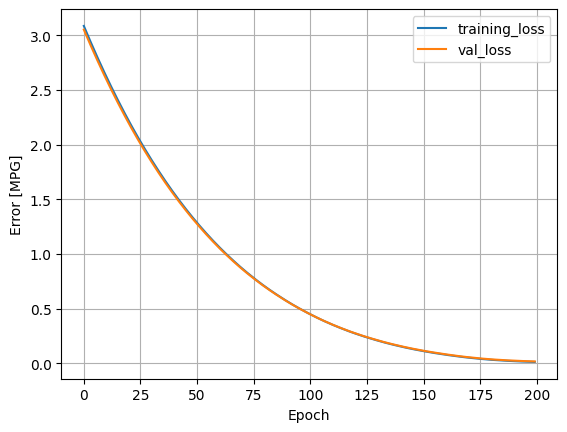

In [120]:
print('Average Train Loss= {:.2}'.format(np.mean(train_loss)))
print('Average Validation Loss = {:.2}'.format(np.mean(val_loss)))
print('Average Test Loss = {:.2}'.format(np.mean(test_loss)))
print('Test Loss = {:.2}'.format(root_mean_squared_error(test_y_true[tickers], test_preds[tickers])))

def plot_loss(history):
  plt.plot(history.history['loss'], label='training_loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  #plt.ylim([0, 10])
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)
plot_loss(history_all[0])

In [121]:
test_preds.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT,Date
130,0.028727,0.026505,0.028939,0.023898,0.028012,0.033167,0.028954,0.034888,0.040698,0.041792,...,0.048235,0.048607,0.051071,0.026329,0.039153,0.046370,0.024494,0.027014,0.050748,2022-01-01
131,0.030131,0.027221,0.029087,0.025453,0.028246,0.041986,0.027445,0.032983,0.049742,0.036150,...,0.046436,0.050336,0.047909,0.027058,0.041682,0.036957,0.023858,0.026878,0.049987,2022-02-01
132,0.030004,0.027683,0.035040,0.024619,0.027130,0.059922,0.029065,0.032281,0.056707,0.037670,...,0.047922,0.044998,0.046304,0.031569,0.035760,0.039275,0.022528,0.027379,0.042889,2022-03-01
133,0.025886,0.028960,0.031116,0.027295,0.031701,0.043508,0.030114,0.036321,0.043196,0.040018,...,0.047671,0.045149,0.045690,0.028070,0.039467,0.036903,0.026821,0.025602,0.052760,2022-04-01
134,0.027089,0.027104,0.036029,0.027629,0.027915,0.044582,0.028082,0.034641,0.044072,0.039125,...,0.046426,0.050099,0.053170,0.027788,0.030594,0.037959,0.024734,0.033129,0.046477,2022-05-01


In [ ]:
#test_preds_rounded.iloc[::,:29].sum(axis=1)

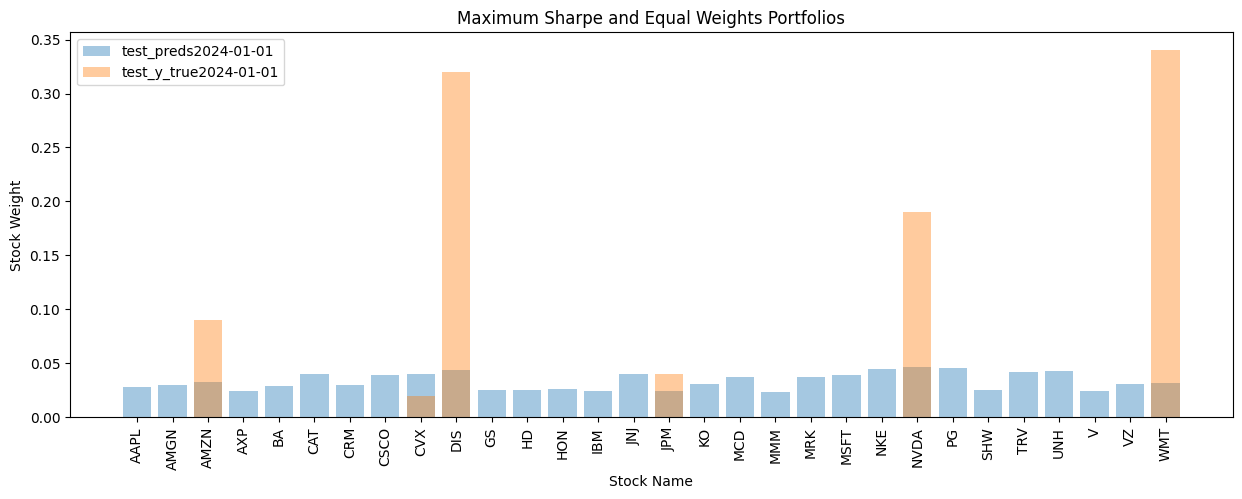

In [122]:
date1 = '2024-01-01'
#date2 = '2023-01-01'
#tickers = min_var_weights_with_target.iloc[::,:29].columns.tolist()
plt.subplots(figsize=(15,5))
plt.title('Maximum Sharpe and Equal Weights Portfolios')
plt.bar(tickers, test_preds[test_preds.Date == date1][tickers].values[0], alpha=0.4, label='test_preds'+date1)
plt.bar(tickers, test_y_true[test_y_true.Date == date1][tickers].values[0], alpha=0.4, label='test_y_true'+date1)
plt.xlabel('Stock Name')
plt.ylabel('Stock Weight')
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [123]:
test_preds.shape

(34, 31)

In [124]:
test_preds.to_pickle('datasets/test_data_m2_weights.pkl')

## Evaluation

In [125]:
method2_weights = pd.read_pickle('datasets/test_data_m2_weights.pkl')
test_df = pd.read_pickle('datasets/test_data_m1_month.pkl')

In [126]:
method2_weights.shape

(34, 31)

In [127]:
#min_var_capital
unique_trade_date = method2_weights.Date.unique()
test_df_pivot = test_df.pivot(index='Date', columns='Ticker', values='close')
portfolio = pd.DataFrame(index = unique_trade_date[:-1], columns = ['account_value'])
initial_capital = 1000000
portfolio.loc[unique_trade_date[0],'account_value'] = initial_capital
method2_capital =  capital(method2_weights.set_index('Date'), test_df_pivot,unique_trade_date,portfolio)

Sharpe Ratio: 0.8267925396632996
Annual Return: 0.1330086380925557


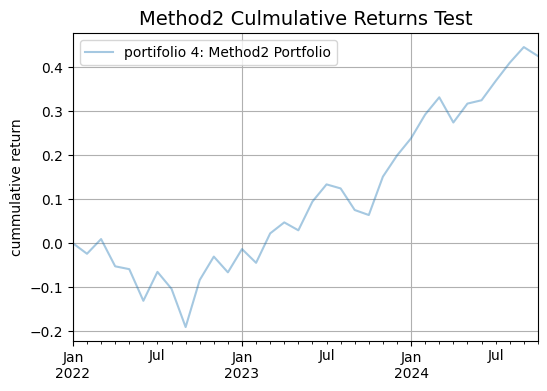

In [128]:
#method2
method2_returns = method2_capital.account_value.pct_change()
method2_cumpod =(method2_capital.account_value.pct_change().fillna(0)+1).cumprod()-1
method2_cumpod.name = "portifolio 4: Method2 Portfolio"

fig, ax = plt.subplots(figsize=(6,4))
method2_cumpod.plot(ax=ax, alpha=0.4);

plt.legend(loc="best");
plt.grid(True)
ax.set_ylabel("cummulative return");
ax.set_title('Method2 Culmulative Returns Test', fontsize=14)

print('Sharpe Ratio:', sharpe_ratio(method2_returns.values, period='monthly'))
print('Annual Return:', annual_return(method2_returns.values, period='monthly'))